In [7]:
import subprocess
subprocess.run(['pip', 'install', 'requests'])


CompletedProcess(args=['pip', 'install', 'requests'], returncode=0)

In [8]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
cities = {
    "Abuja":   {"lat": 9.0765,  "lon": 7.3986},
    "Lagos":   {"lat": 6.5244,  "lon": 3.3792},
    "Accra":   {"lat": 5.6037,  "lon": -0.1870},
    "Nairobi": {"lat": -1.2921, "lon": 36.8219}
}

In [10]:
def get_solar_data(lat, lon, start_year=2014, end_year=2025):
    """
    Fetches 11 years of monthly solar irradiance data
    from NASA POWER API for a given location.
    """
    url = "https://power.larc.nasa.gov/api/temporal/monthly/point"
    
    params = {
        "parameters": "ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,ALLSKY_SFC_SW_DIFF",
        "community": "RE",
        "longitude": lon,
        "latitude": lat,
        "start": start_year,
        "end": end_year,
        "format": "JSON"
    }
    
    response = requests.get(url, params=params)
    
    if response.status_code == 200:
        print("✓ Data fetched successfully")
        return response.json()
    else:
        print(f"✗ Error: {response.status_code}")
        return None

In [11]:
# Fetch solar data for all 4 cities
solar_data = {}

for city, coords in cities.items():
    print(f"Fetching data for {city}...")
    solar_data[city] = get_solar_data(coords['lat'], coords['lon'])
    
print("\n✓ All cities fetched!")

Fetching data for Abuja...
✓ Data fetched successfully
Fetching data for Lagos...
✓ Data fetched successfully
Fetching data for Accra...
✓ Data fetched successfully
Fetching data for Nairobi...
✓ Data fetched successfully

✓ All cities fetched!


In [12]:
# Extract GHI data for each city into a dataframe
all_cities_ghi = {}

for city in cities:
    # Get the GHI parameter (ALLSKY_SFC_SW_DWN)
    ghi_raw = solar_data[city]['properties']['parameter']['ALLSKY_SFC_SW_DWN']
    
    # Convert to dataframe
    df_city = pd.DataFrame(list(ghi_raw.items()), columns=['Date', 'GHI'])
    
    # Filter out annual summaries (keep only monthly — format YYYYMM not YYYYANN)
    df_city = df_city[~df_city['Date'].str.endswith('13')]
    
    # Extract year and month
    df_city['Year'] = df_city['Date'].str[:4].astype(int)
    df_city['Month'] = df_city['Date'].str[4:].astype(int)
    df_city['City'] = city
    
    all_cities_ghi[city] = df_city

# Combine all cities into one dataframe
ghi_df = pd.concat(all_cities_ghi.values(), ignore_index=True)
print(ghi_df.shape)
print(ghi_df.head(10))

(576, 5)
     Date     GHI  Year  Month   City
0  201401  5.4934  2014      1  Abuja
1  201402  5.5798  2014      2  Abuja
2  201403  5.7526  2014      3  Abuja
3  201404  5.7511  2014      4  Abuja
4  201405  5.2097  2014      5  Abuja
5  201406  5.1010  2014      6  Abuja
6  201407  4.2770  2014      7  Abuja
7  201408  3.9914  2014      8  Abuja
8  201409  4.6272  2014      9  Abuja
9  201410  5.4674  2014     10  Abuja


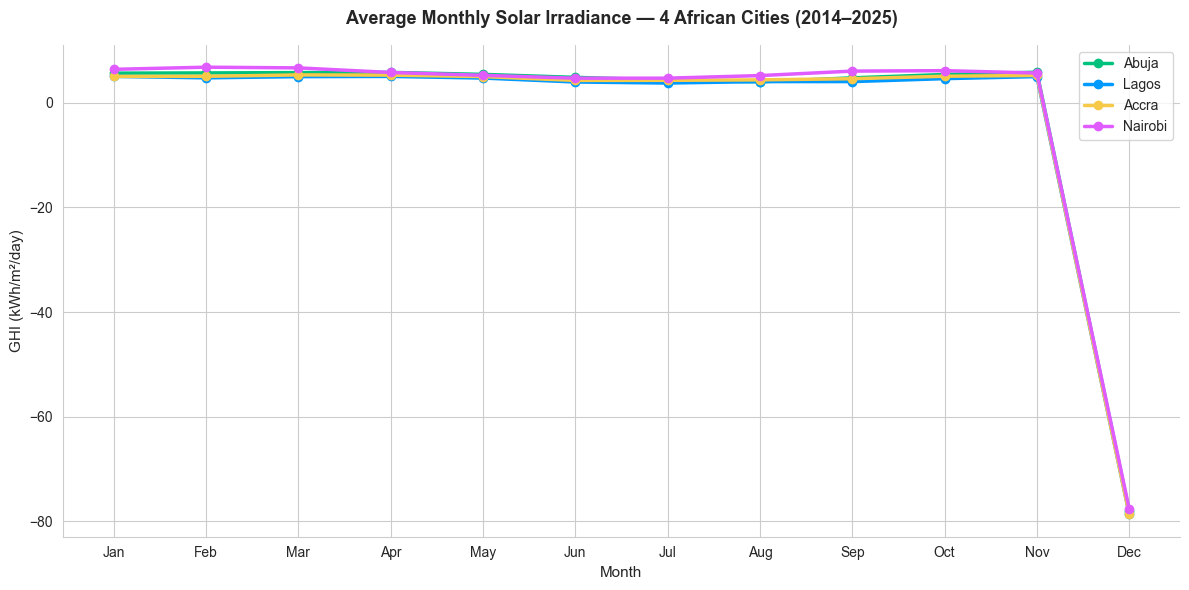

Chart saved!


In [13]:
# Calculate average GHI by month for each city (across all years)
monthly_avg = ghi_df.groupby(['City', 'Month'])['GHI'].mean().reset_index()

# Month names for x-axis
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    'Abuja':   '#00c27c',
    'Lagos':   '#0099ff',
    'Accra':   '#f7c948',
    'Nairobi': '#e05cff'
}

for city in cities:
    city_data = monthly_avg[monthly_avg['City'] == city]
    ax.plot(
        month_names,
        city_data['GHI'].values,
        marker='o',
        linewidth=2.5,
        markersize=6,
        label=city,
        color=colors[city]
    )

ax.set_title('Average Monthly Solar Irradiance — 4 African Cities (2014–2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('GHI (kWh/m²/day)', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/solar_ghi_monthly_avg.png', dpi=150)
plt.show()
print("Chart saved!")

In [15]:
# Remove NASA fill values (-999) — these represent missing data
ghi_df = ghi_df[ghi_df['GHI'] > 0]

# Recalculate monthly averages with clean data
monthly_avg = ghi_df.groupby(['City', 'Month'])['GHI'].mean().reset_index()

print("Clean data shape:", ghi_df.shape)
print("\nMin GHI value:", ghi_df['GHI'].min())
print("Max GHI value:", ghi_df['GHI'].max())

Clean data shape: (572, 5)

Min GHI value: 3.367
Max GHI value: 7.3872


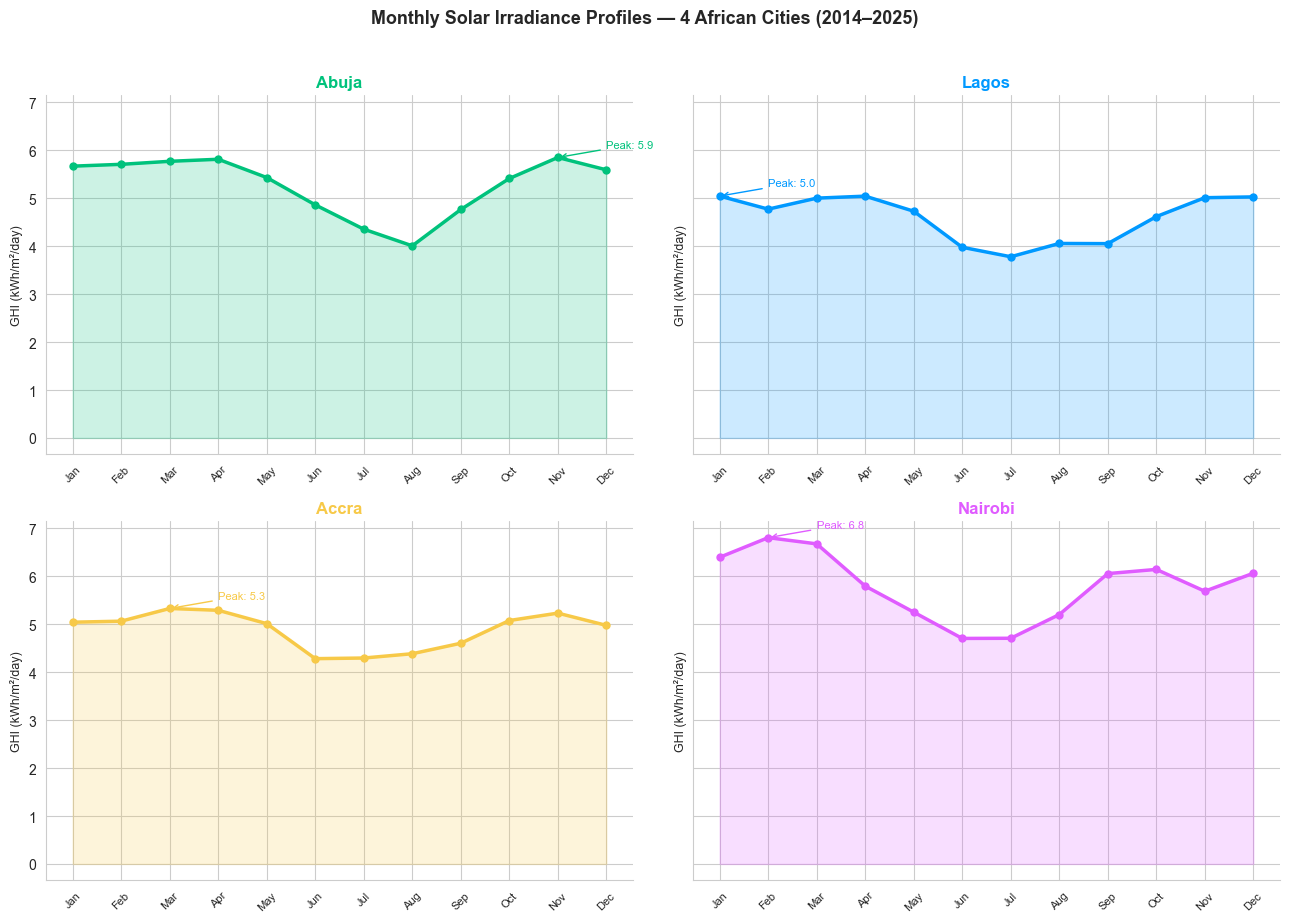

Chart saved!


In [17]:
# Separate subplots for each city — easier to read individual patterns
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
axes = axes.flatten()

for idx, city in enumerate(cities):
    city_data = monthly_avg[monthly_avg['City'] == city]
    ax = axes[idx]
    
    ax.fill_between(
        month_names,
        city_data['GHI'].values,
        alpha=0.2,
        color=colors[city]
    )
    ax.plot(
        month_names,
        city_data['GHI'].values,
        marker='o',
        linewidth=2.5,
        markersize=5,
        color=colors[city],
        label=city
    )
    
    # Add peak annotation
    peak_idx = city_data['GHI'].values.argmax()
    peak_val = city_data['GHI'].values.max()
    ax.annotate(
        f'Peak: {peak_val:.1f}',
        xy=(month_names[peak_idx], peak_val),
        xytext=(peak_idx + 1, peak_val + 0.2),
        fontsize=8,
        color=colors[city],
        arrowprops=dict(arrowstyle='->', color=colors[city], lw=1)
    )
    
    ax.set_title(city, fontsize=12, fontweight='bold', color=colors[city])
    ax.set_ylabel('GHI (kWh/m²/day)', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelsize=8, rotation=45)

fig.suptitle('Monthly Solar Irradiance Profiles — 4 African Cities (2014–2025)',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../reports/solar_ghi_subplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Chart Interpretation — Monthly Solar Irradiance (2014–2025)

The chart illustrates the average monthly solar irradiance across four African cities between 2014 and 2025.

Nairobi records the highest overall irradiance levels. The city sits at an altitude of approximately 1,795 metres above sea level, and its elevated position means a thinner atmosphere and reduced scattering of incoming solar radiation, allowing more sunlight to reach the surface. This helps explain why Kenya has emerged as one of Africa's leading solar energy markets despite not being among the continent's hottest countries.

The noticeable irradiance peaks around November and December are also significant. For cities located close to the equator, such as Nairobi and Accra, solar intensity tends to peak around the equinox periods when the sun is positioned more directly overhead, maximising solar exposure.

Abuja exhibits a strong seasonal cycle, with higher irradiance during the dry season (roughly November to March) and lower values during the rainy season (July to September). This fluctuation is largely influenced 
by the West African monsoon system and is a critical consideration in solar farm sizing, storage planning, and energy yield forecasting.

One particularly insightful feature is the unexpected dip in irradiance during December despite it falling within the dry season. This decline is likely linked to the Harmattan, the dry dusty wind blowing from the 
Sahara across West Africa. The suspended dust particles scatter and absorb solar radiation, temporarily reducing solar intensity despite clear skies. This demonstrates how atmospheric conditions, not just sunshine duration, can significantly influence solar energy performance.

Note: December 2025 data was excluded from this analysis as NASA POWER had not yet published complete data for that period at the time of access.

In [18]:
def analyse_city_solar(city_name, lat, lon, start_year=2014, end_year=2025):
    """
    Complete solar analysis pipeline for any city.
    Fetches NASA POWER data, cleans it, and generates
    a monthly GHI profile chart automatically.
    
    Parameters:
        city_name  : string — name of the city
        lat        : float  — latitude coordinate
        lon        : float  — longitude coordinate
        start_year : int    — start year for data (default 2014)
        end_year   : int    — end year for data (default 2025)
    """
    print(f"Fetching solar data for {city_name}...")
    
    # Step 1 — Fetch data
    raw_data = get_solar_data(lat, lon, start_year, end_year)
    if not raw_data:
        print(f"Failed to fetch data for {city_name}")
        return None
    
    # Step 2 — Extract and clean GHI
    ghi_raw = raw_data['properties']['parameter']['ALLSKY_SFC_SW_DWN']
    df = pd.DataFrame(list(ghi_raw.items()), columns=['Date', 'GHI'])
    df = df[~df['Date'].str.endswith('13')]
    df = df[df['GHI'] > 0]
    df['Year'] = df['Date'].str[:4].astype(int)
    df['Month'] = df['Date'].str[4:].astype(int)
    
    # Step 3 — Monthly averages
    monthly_avg = df.groupby('Month')['GHI'].mean()
    
    # Step 4 — Summary statistics
    annual_avg = monthly_avg.mean()
    peak_month = month_names[monthly_avg.idxmax() - 1]
    low_month = month_names[monthly_avg.idxmin() - 1]
    
    print(f"\n{'='*45}")
    print(f"  Solar Analysis — {city_name}")
    print(f"{'='*45}")
    print(f"  Annual Average GHI : {annual_avg:.2f} kWh/m²/day")
    print(f"  Peak Month         : {peak_month} ({monthly_avg.max():.2f} kWh/m²/day)")
    print(f"  Lowest Month       : {low_month} ({monthly_avg.min():.2f} kWh/m²/day)")
    print(f"  Seasonal Variation : {monthly_avg.max() - monthly_avg.min():.2f} kWh/m²/day")
    print(f"{'='*45}\n")
    
    # Step 5 — Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.fill_between(month_names, monthly_avg.values, alpha=0.2, color='#00c27c')
    ax.plot(month_names, monthly_avg.values, marker='o', linewidth=2.5,
            markersize=6, color='#00c27c')
    
    # Annotate peak
    peak_idx = monthly_avg.values.argmax()
    ax.annotate(
        f'Peak: {monthly_avg.max():.1f}',
        xy=(month_names[peak_idx], monthly_avg.max()),
        xytext=(peak_idx + 1, monthly_avg.max() + 0.1),
        fontsize=9, color='#00c27c',
        arrowprops=dict(arrowstyle='->', color='#00c27c', lw=1)
    )
    
    # Annual average line
    ax.axhline(y=annual_avg, color='orange', linestyle='--',
               linewidth=1.5, label=f'Annual avg: {annual_avg:.2f} kWh/m²/day')
    
    ax.set_title(f'Monthly Solar Irradiance Profile — {city_name} ({start_year}–{end_year})',
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Month', fontsize=11)
    ax.set_ylabel('GHI (kWh/m²/day)', fontsize=11)
    ax.legend(fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    
    plt.tight_layout()
    
    # Save chart
    filename = f"../reports/solar_{city_name.lower().replace(' ', '_')}.png"
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"Chart saved to {filename}")
    
    return df

Fetching solar data for Kano...
✓ Data fetched successfully

  Solar Analysis — Kano
  Annual Average GHI : 5.97 kWh/m²/day
  Peak Month         : Apr (6.61 kWh/m²/day)
  Lowest Month       : Aug (5.35 kWh/m²/day)
  Seasonal Variation : 1.26 kWh/m²/day



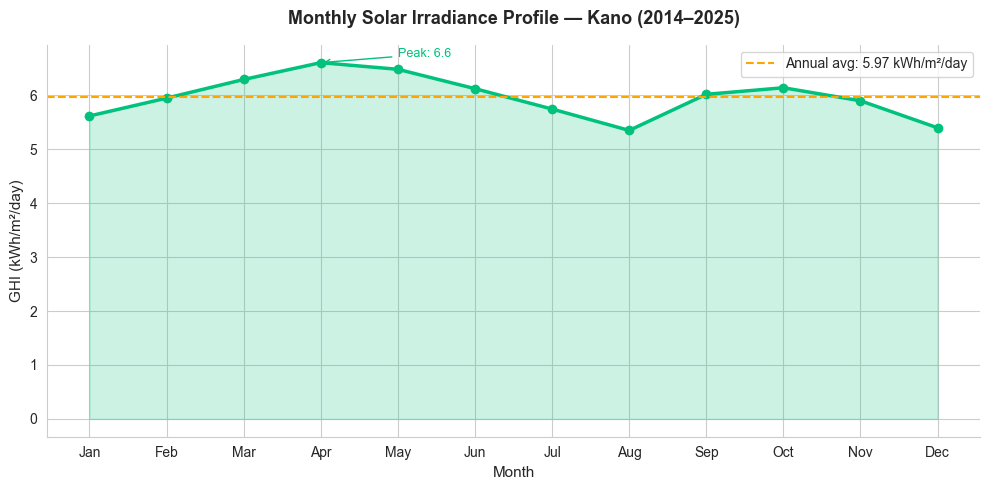

Chart saved to ../reports/solar_kano.png


In [19]:
# Test the function on Kano — Nigeria's northern solar capital
kano_data = analyse_city_solar("Kano", lat=12.0022, lon=8.5920)

# Kano tells a fascinating story:
Annual Average of 5.97 kWh/m²/day, which is higher than both Lagos (5.0) and Accra (5.3). Kano's Sahelian climate with minimal cloud cover drives that up significantly.

Peaks in April which is different from the coastal cities. Further north means the sun's overhead position shifts the peak earlier in the year, before the rainy season arrives.

Lowest in August. The rainy season dip is clear even this far north. The seasonal variation of only 1.26 kWh/m²/day is a remarkably consistent output year round which is ery attractive for solar investment planning.

The big takeaway is that Kano has better solar potential than Lagos despite Lagos being further south. Geography and climate matter more than latitude alone.
.

Fetching solar data for Kampala...
✓ Data fetched successfully

  Solar Analysis — Kampala
  Annual Average GHI : 5.24 kWh/m²/day
  Peak Month         : Feb (5.77 kWh/m²/day)
  Lowest Month       : Jul (4.75 kWh/m²/day)
  Seasonal Variation : 1.02 kWh/m²/day



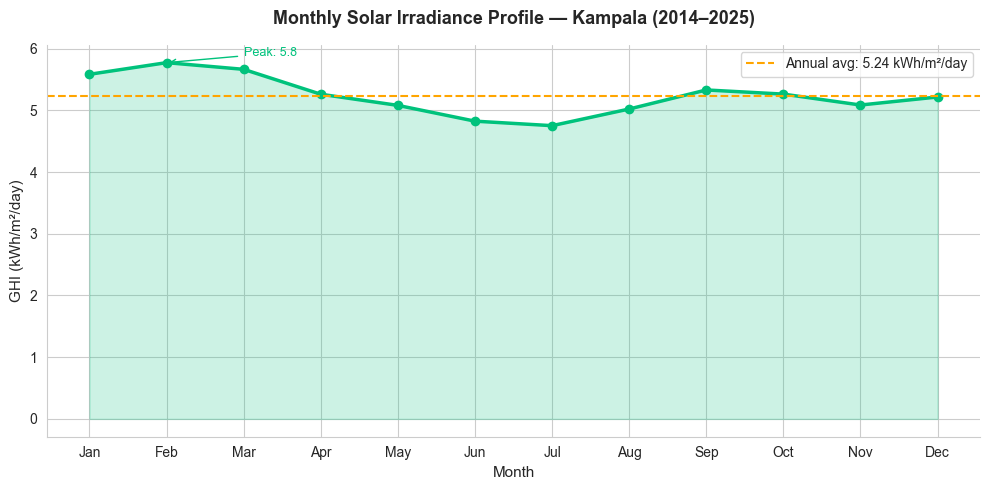

Chart saved to ../reports/solar_kampala.png


In [20]:
kampala_data = analyse_city_solar("Kampala", lat=0.3476, lon=32.5825)


Fetching solar data for Windhoek...
✓ Data fetched successfully

  Solar Analysis — Windhoek
  Annual Average GHI : 6.35 kWh/m²/day
  Peak Month         : Nov (7.83 kWh/m²/day)
  Lowest Month       : Jun (4.74 kWh/m²/day)
  Seasonal Variation : 3.09 kWh/m²/day



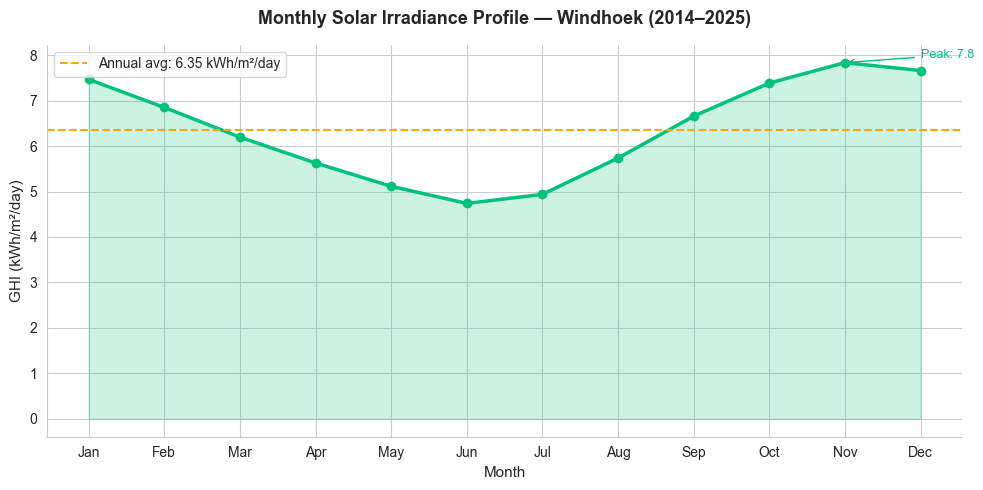

Chart saved to ../reports/solar_windhoek.png


In [21]:
windhoek_data = analyse_city_solar("Windhoek", lat=-22.5609, lon=17.0658)

# Kampala and Windhoek
Kampala's annual average of 5.24 kWh/m²/day may not look extreme at first glance, but the real strength lies in its consistency. Being close to the equator gives Kampala relatively stable solar exposure throughout the year, with very little seasonal fluctuation.

It peaks in February (5.77 kWh/m²/day), when the sun is positioned more directly overhead and cloud cover is relatively lower. Unlike cities further from the equator, Kampala does not experience dramatic seasonal swings in solar intensity.

Its lowest month is July (4.75 kWh/m²/day), but even then, the drop is relatively small. A seasonal variation of just 1.02 kWh/m²/day is exceptionally stable and highly attractive for reliable year-round solar generation.

The big takeaway is that Kampala may not have the highest irradiance in Africa, but it offers one of the most predictable solar profiles. For grid stability, mini-grids, and long-term energy planning, consistency can sometimes be more valuable than extreme peaks.

## Windhoek tells a very different story:
It's annual average of 6.35 kWh/m²/day places Windhoek among the strongest solar resource zones in Africa. Its high altitude, dry desert climate, and minimal cloud cover combine to produce extremely intense solar radiation.

It peaks sharply in November (7.83 kWh/m²/day), reflecting the strong summer solar conditions typical of Southern Africa. Unlike equatorial cities, Windhoek experiences much stronger seasonal contrasts as the sun angle changes significantly throughout the year.

Its lowest month is June (4.74 kWh/m²/day) during the Southern Hemisphere winter. The seasonal variation of 3.09 kWh/m²/day is very large, showing that while Windhoek has exceptional solar potential, it is also far more seasonal and variable than Kampala.

The big takeaway is that Windhoek represents a high-output solar environment capable of massive energy generation, but with greater fluctuations across the year. It highlights how desert climates can produce world-class solar intensity, though often with stronger seasonal dependence than equatorial regions.

In [22]:
# Summary comparison table for all 6 cities
summary_data = {
    'City':              ['Windhoek', 'Nairobi', 'Kano', 'Abuja', 'Accra', 'Lagos', 'Kampala'],
    'Country':           ['Namibia', 'Kenya', 'Nigeria', 'Nigeria', 'Ghana', 'Nigeria', 'Uganda'],
    'Annual Avg GHI':    [6.35, 5.79, 5.97, 5.49, 5.03, 4.78, 5.24],
    'Peak Month':        ['Nov', 'Feb', 'Apr', 'Nov', 'Mar', 'Jan', 'Feb'],
    'Peak GHI':          [7.83, 6.80, 6.61, 5.90, 5.30, 5.00, 5.77],
    'Lowest Month':      ['Jun', 'Jul', 'Aug', 'Aug', 'Jul', 'Jul', 'Jul'],
    'Seasonal Variation':[3.09, 2.06, 1.26, 1.54, 0.97, 1.19, 1.02],
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Annual Avg GHI', ascending=False)
print("=== Solar Potential Ranking — 6 African Cities ===")
print(summary_df.to_string(index=False))

=== Solar Potential Ranking — 6 African Cities ===
    City Country  Annual Avg GHI Peak Month  Peak GHI Lowest Month  Seasonal Variation
Windhoek Namibia            6.35        Nov      7.83          Jun                3.09
    Kano Nigeria            5.97        Apr      6.61          Aug                1.26
 Nairobi   Kenya            5.79        Feb      6.80          Jul                2.06
   Abuja Nigeria            5.49        Nov      5.90          Aug                1.54
 Kampala  Uganda            5.24        Feb      5.77          Jul                1.02
   Accra   Ghana            5.03        Mar      5.30          Jul                0.97
   Lagos Nigeria            4.78        Jan      5.00          Jul                1.19


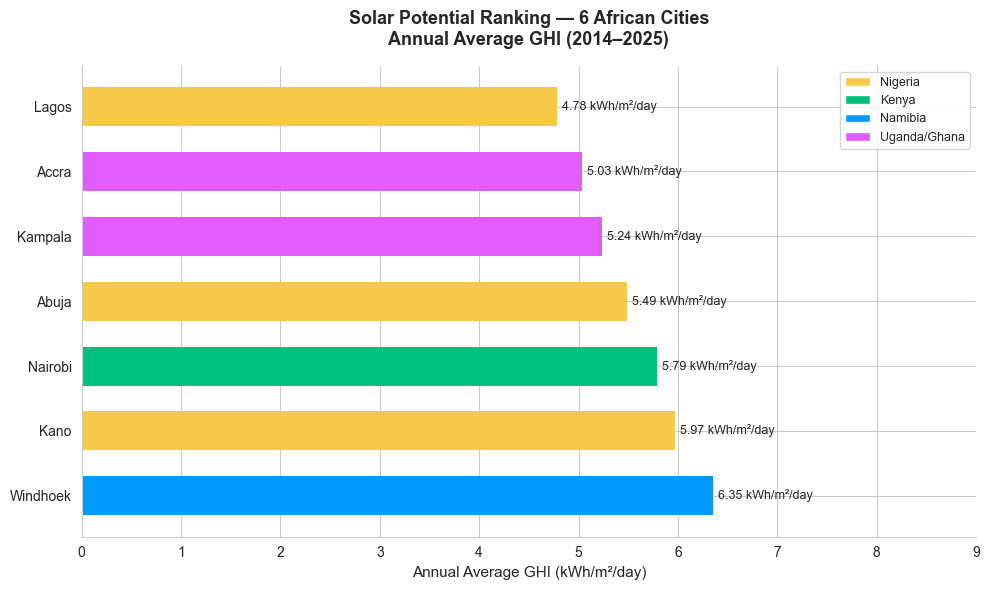

Chart saved!


In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

colors_bar = ['#f7c948' if c == 'Nigeria' else
              '#00c27c' if c == 'Kenya' else
              '#0099ff' if c == 'Namibia' else
              '#e05cff' for c in summary_df['Country']]

bars = ax.barh(
    summary_df['City'],
    summary_df['Annual Avg GHI'],
    color=colors_bar,
    edgecolor='none',
    height=0.6
)

# Value labels
for bar, val in zip(bars, summary_df['Annual Avg GHI']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f} kWh/m²/day', va='center', fontsize=9)

ax.set_title('Solar Potential Ranking — 6 African Cities\nAnnual Average GHI (2014–2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Annual Average GHI (kWh/m²/day)', fontsize=11)
ax.set_xlim(0, 9)
ax.spines[['top', 'right']].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#f7c948', label='Nigeria'),
    Patch(facecolor='#00c27c', label='Kenya'),
    Patch(facecolor='#0099ff', label='Namibia'),
    Patch(facecolor='#e05cff', label='Uganda/Ghana'),
]
ax.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig('../reports/solar_city_ranking.png', dpi=150)
plt.show()
print("Chart saved!")

# Solar potential rankings for 6-African cities

 Namibia is genuinely one of the best solar locations on the planet. Windhoek leads at 6.35 kWh/m²/day. The 3.09 seasonal variation is the highest of all cities, meaning strong peaks but notable winter dips. Good for utility-scale solar with storage.

Kano at 5.97 is Nigeria's best solar city, beating Abuja, Lagos, and even Nairobi. Completely underutilised. A northern Nigeria solar investment story waiting to be told.

Nairobi at 5.79 is high altitude advantage confirmed. Two distinct peaks matching Kenya's two dry seasons.

Kampala at 5.24 is modest but remarkably consistent. Seasonal variation of just 1.02 is the lowest of all 6 cities. Near-equatorial position means almost no seasonal swing. Reliable year-round output.

Lagos at 4.78 is the lowest of the 6 despite being Nigeria's commercial hub. Coastal humidity and cloud cover are the culprits. Rooftop solar works here but utility-scale projects should look north to Kano.